===== Product Feedback Classification System - Logistic Regression Baseline Model =====
Loading data from X_train_cleaned.csv and y_train_cleaned.csv...
X shape: (9690, 300), y shape: (9690, 1)

Dataset Analysis:
Number of samples: 9690
Number of features: 300
Number of classes: 28
Samples in the majority class: 4372 (45.12%)
Samples in the minority class: 6
Class imbalance ratio: 728.67

Top 10 classes by frequency:
Class 5: 4372 (45.12%)
Class 10: 1042 (10.75%)
Class 6: 530 (5.47%)
Class 8: 490 (5.06%)
Class 12: 442 (4.56%)
Class 24: 372 (3.84%)
Class 17: 342 (3.53%)
Class 26: 273 (2.82%)
Class 21: 261 (2.69%)
Class 14: 257 (2.65%)

Feature distribution summary:
       mean       std     min     max
0 -0.019430  0.954816 -4.0083  3.9436
1  0.018715  0.923544 -3.4949  4.2322
2 -0.014712  0.967468 -3.5020  4.2948
3  0.050038  0.964767 -4.2947  3.8679
4  0.032292  0.958073 -3.9771  4.4009
Number of missing values: 0
Class distribution plot saved as 'class_distribution.png'

Data preproc

/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/dav

Confusion matrix saved as 'confusion_matrix.png'

Feature importance analysis:

Top 10 most important features:
         Feature  Importance
130  feature_130    0.242386
281  feature_281    0.222489
159  feature_159    0.216946
19    feature_19    0.209080
177  feature_177    0.208953
66    feature_66    0.207411
37    feature_37    0.203977
157  feature_157    0.198023
50    feature_50    0.197745
155  feature_155    0.197231
Feature importance plot saved as 'feature_importance.png'

 Model Training and Evaluation Complete 


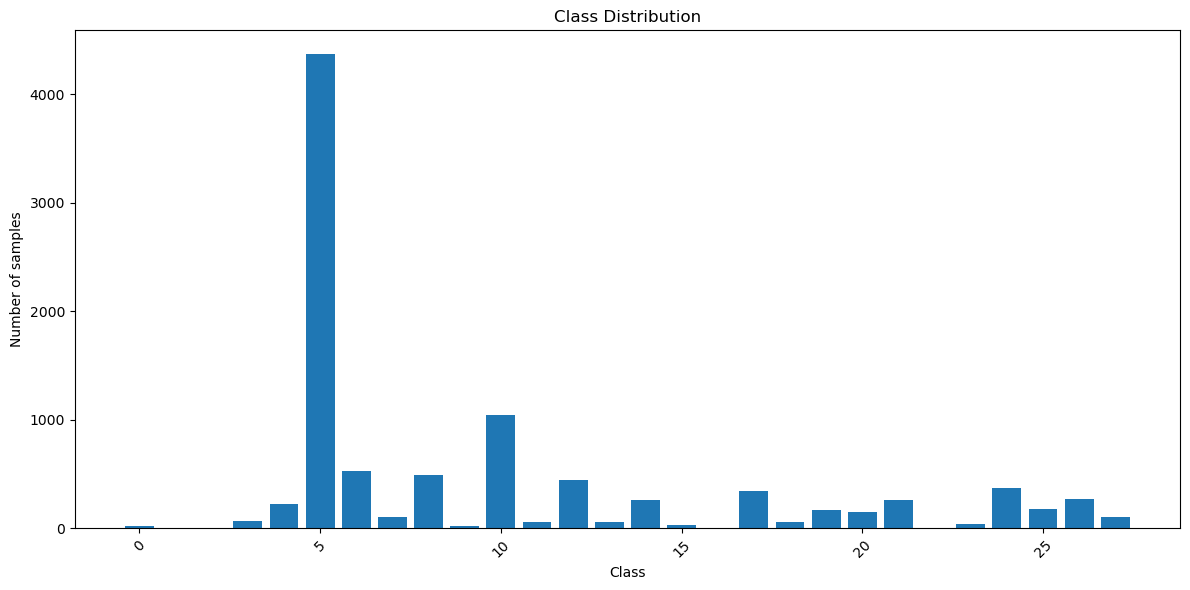

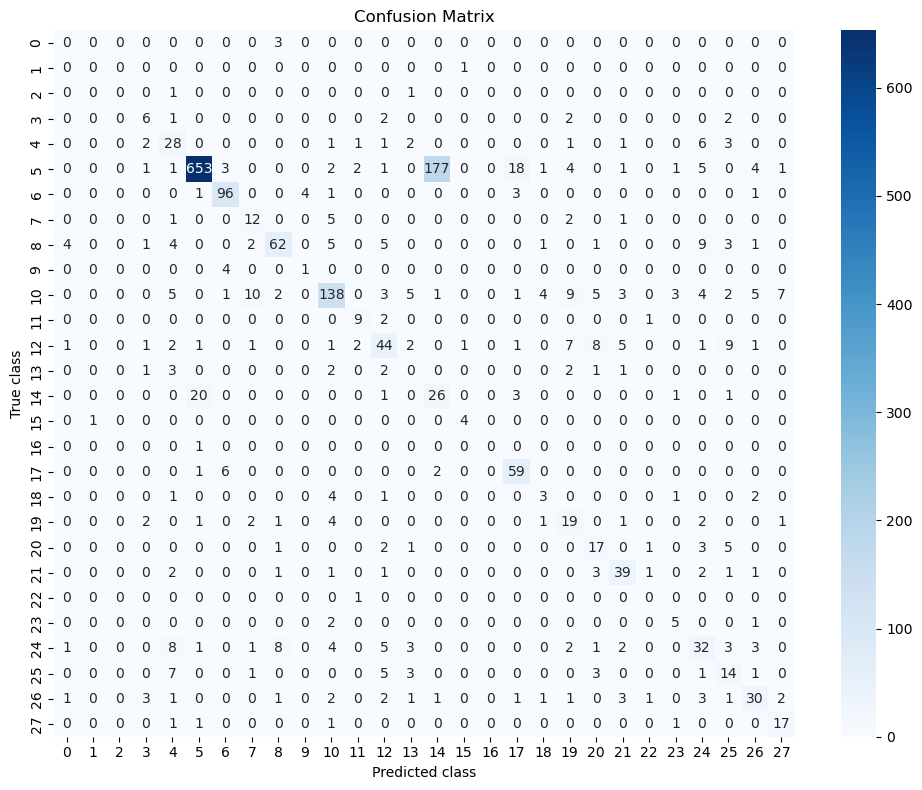

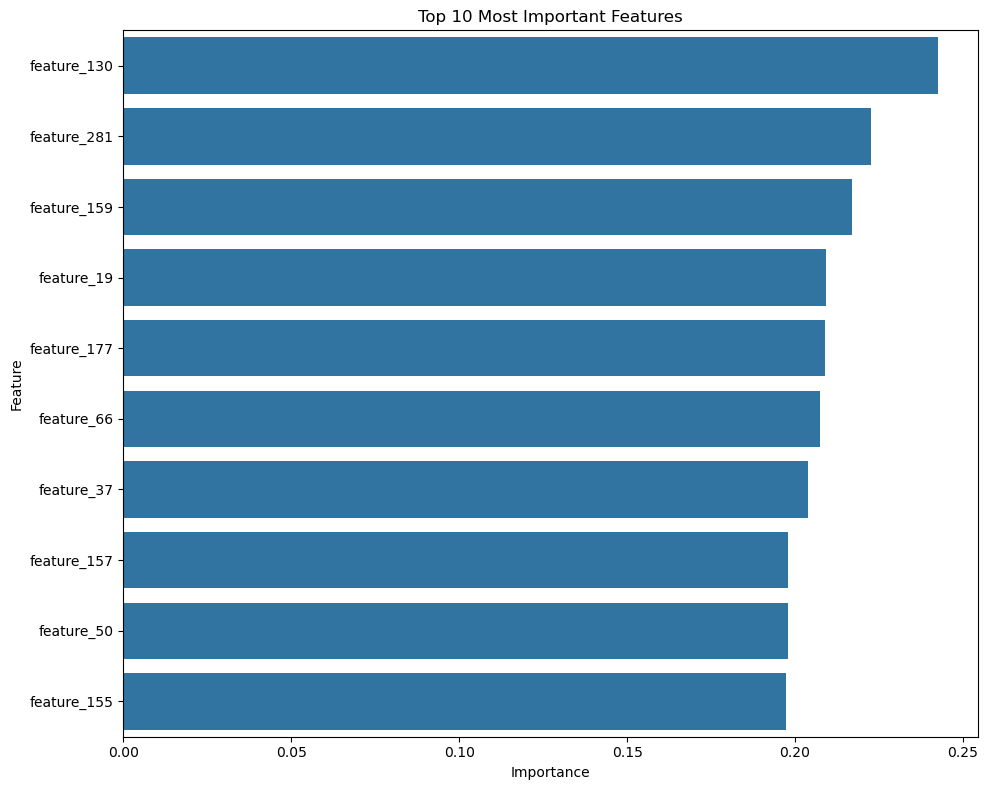

In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

"""
Logistic Regression Baseline Model - Product Feedback Classification System

This script implements a multiclass logistic regression model to classify customer comments
into 28 different product departments. The dataset contains 10,000 samples, each with
300 features extracted through NLP techniques.
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import log_loss

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

def load_data(x_path, y_path):
    """
    Load feature and label data
    
    Parameters:
    x_path: Path to the CSV file with features
    y_path: Path to the CSV file with labels
    
    Returns:
    X: Feature matrix
    y: Label vector
    """
    print(f"Loading data from {x_path} and {y_path}...")
    X = pd.read_csv(x_path)
    y = pd.read_csv(y_path)
    print(f"X shape: {X.shape}, y shape: {y.shape}")
    return X, y['label']

def analyze_data(X, y):
    """
    Analyze data distribution
    
    Parameters:
    X: Feature matrix
    y: Label vector
    """
    print("\nDataset Analysis:")
    print(f"Number of samples: {X.shape[0]}")
    print(f"Number of features: {X.shape[1]}")
    
    # Analyze label distribution
    class_counts = Counter(y)
    num_classes = len(class_counts)
    print(f"Number of classes: {num_classes}")
    
    # Calculate class imbalance metrics
    majority_class = max(class_counts.values())
    minority_class = min(class_counts.values())
    imbalance_ratio = majority_class / minority_class
    
    print(f"Samples in the majority class: {majority_class} ({majority_class/len(y)*100:.2f}%)")
    print(f"Samples in the minority class: {minority_class}")
    print(f"Class imbalance ratio: {imbalance_ratio:.2f}")
    
    # Print the top 10 classes by frequency
    sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
    print("\nTop 10 classes by frequency:")
    for class_label, count in sorted_classes[:10]:
        print(f"Class {class_label}: {count} ({count/len(y)*100:.2f}%)")
    
    # Check feature distribution
    print("\nFeature distribution summary:")
    feature_summary = X.describe().T[['mean', 'std', 'min', 'max']]
    print(feature_summary.head())
    
    # Check for missing values
    missing_values = X.isnull().sum().sum()
    print(f"Number of missing values: {missing_values}")
    
    return class_counts

def plot_class_distribution(class_counts):
    """
    Plot class distribution
    
    Parameters:
    class_counts: Dictionary with class counts
    """
    plt.figure(figsize=(12, 6))
    sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
    labels, counts = zip(*sorted_counts)
    
    plt.bar(labels, counts)
    plt.xlabel('Class')
    plt.ylabel('Number of samples')
    plt.title('Class Distribution')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('class_distribution.png')
    print("Class distribution plot saved as 'class_distribution.png'")

def train_logistic_regression(X_train, y_train, X_val, y_val, class_counts):
    """
    Train logistic regression model
    
    Parameters:
    X_train: Training features
    y_train: Training labels
    X_val: Validation features
    y_val: Validation labels
    class_counts: Dictionary with class counts
    
    Returns:
    model: Trained model
    """
    print("\nTraining logistic regression model...")
    
    # Calculate class weights to handle class imbalance
    total_samples = sum(class_counts.values())
    class_weights = {label: total_samples / (len(class_counts) * count) 
                    for label, count in class_counts.items()}
    
    # Create logistic regression model
    model = LogisticRegression(
        multi_class='multinomial',  # Multinomial logistic regression
        solver='lbfgs',             # Optimization algorithm
        C=0.215,                      # Inverse of regularization strength (smaller C = stronger regularization)
        max_iter=1000,              # Maximum number of iterations
        class_weight=class_weights, # Use class weights to handle imbalance
        random_state=RANDOM_SEED
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Evaluate on validation set
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    print(f"Validation accuracy: {accuracy:.4f}")
    
    return model

def evaluate_model(model, X_val, y_val):
    """
    Evaluate model performance
    
    Parameters:
    model: Trained model
    X_val: Validation features
    y_val: Validation labels
    """
    print("\nDetailed model evaluation:")
    
    # Generate predictions
    y_pred = model.predict(X_val)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    
    # Calculate metrics
    report = classification_report(y_val, y_pred, output_dict=True)
    
    # Print classification report
    print(classification_report(y_val, y_pred))
    
    # Calculate and print accuracy per class
    class_accuracies = {}
    for i in range(len(cm)):
        if i in y_val.values:
            class_accuracies[i] = cm[i, i] / np.sum(cm[i, :])
    
    print("\nAccuracy per class:")
    for cls, acc in sorted(class_accuracies.items(), key=lambda x: x[1], reverse=True):
        print(f"Class {cls}: {acc:.4f}")
    
    # Plot confusion matrix heatmap (only for classes with samples)
    active_classes = sorted(set(y_val))
    active_indices = [i for i, cls in enumerate(sorted(set(y_val) | set(y_pred))) if cls in active_classes]
    
    
    plt.figure(figsize=(10, 8))
    cm_subset = cm[np.ix_(active_indices, active_indices)]
    sns.heatmap(cm_subset, annot=True, fmt='d', cmap='Blues',
                xticklabels=active_classes, yticklabels=active_classes)
    plt.xlabel('Predicted class')
    plt.ylabel('True class')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    print("Confusion matrix saved as 'confusion_matrix.png'")
    
    return report

def analyze_feature_importance(model, feature_names):
    """
    Analyze feature importance
    
    Parameters:
    model: Trained model
    feature_names: List of feature names
    """
    print("\nFeature importance analysis:")
    
    # For logistic regression, we use the absolute values of coefficients as feature importance
    # For multiclass problems, we take the average absolute value across all classes
    coef = model.coef_  # shape: (n_classes, n_features)
    importances = np.abs(coef).mean(axis=0)
    
    # Create feature importance DataFrame
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    
    # Sort by importance and display top 10 features
    sorted_features = feature_importance.sort_values('Importance', ascending=False)
    print("\nTop 10 most important features:")
    print(sorted_features.head(10))
    
    # Plot top 10 most important features
    plt.figure(figsize=(10, 8))
    top_features = sorted_features.head(10)
    sns.barplot(x='Importance', y='Feature', data=top_features)
    plt.title('Top 10 Most Important Features')
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    print("Feature importance plot saved as 'feature_importance.png'")

def main():
    """
    Main function
    """
    print("===== Product Feedback Classification System - Logistic Regression Baseline Model =====")
    
    # Data file paths
    x_path = 'X_train_cleaned.csv'
    y_path = 'y_train_cleaned.csv'
    
    # Load data
    X, y = load_data(x_path, y_path)
    
    # Analyze data
    class_counts = analyze_data(X, y)
    
    # Plot class distribution
    plot_class_distribution(class_counts)
    
    # Data preprocessing
    print("\nData preprocessing...")
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Split into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        X_scaled, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
    )
    print(f"Training set size: {X_train.shape[0]}")
    print(f"Validation set size: {X_val.shape[0]}")
    
    # Train logistic regression model
    model = train_logistic_regression(X_train, y_train, X_val, y_val, class_counts)

   

    # … after train_test_split and model.fit(…) …
    
    # 1. Predict probabilities
    y_train_proba = model.predict_proba(X_train)
    y_val_proba   = model.predict_proba(X_val)
    
    # 2. Compute log‐loss
    train_loss = log_loss(y_train, y_train_proba)
    val_loss   = log_loss(y_val,   y_val_proba)
    
    # 3. Print
    print(f"Training Log Loss:   {train_loss:.4f}")
    print(f"Validation Log Loss: {val_loss:.4f}")

    
    # Evaluate model
    report = evaluate_model(model, X_val, y_val)
    
    # Analyze feature importance
    feature_names = [f'feature_{i}' for i in range(X.shape[1])]
    analyze_feature_importance(model, feature_names)
    
    print("\n Model Training and Evaluation Complete ")

if __name__ == "__main__":
    main()
   

In [7]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, log_loss
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import ADASYN
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

def load_data(x_path, y_path):
    X = pd.read_csv(x_path)
    y = pd.read_csv(y_path)['label']
    return X, y

def analyze_data(X, y):
    counts = Counter(y)
    print(len(y), X.shape[1], len(counts))
    return counts

def plot_class_distribution(counts):
    labels, vals = zip(*sorted(counts.items(), key=lambda x: x[1], reverse=True))
    plt.bar(labels, vals)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('class_distribution.png')

def train_model(X_train, y_train):
    X_res, y_res = ADASYN(random_state=RANDOM_SEED,n_neighbors=3).fit_resample(X_train, y_train)
    model = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
    model.fit(X_res, y_res)
    return model

def evaluate(model, X, y, tag):
    y_pred = model.predict(X)
    print(tag, accuracy_score(y, y_pred))
    print(classification_report(y, y_pred))
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.tight_layout()
    plt.savefig(f'{tag}_confusion_matrix.png')
    plt.clf()

def main():
    X, y = load_data('X_train_cleaned.csv', 'y_train_cleaned.csv')
    counts = analyze_data(X, y)
    plot_class_distribution(counts)
    X_scaled = StandardScaler().fit_transform(X)
    X_train, X_val, y_train, y_val = train_test_split(
        X_scaled, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
    )
    model = train_model(X_train, y_train)
    print('train log loss', log_loss(y_train, model.predict_proba(X_train)))
    print('val   log loss', log_loss(y_val,   model.predict_proba(X_val)))
    evaluate(model, X_val, y_val, 'val')

if __name__ == '__main__':
    main()
    


9690 300 28


/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-sc

train log loss 0.27733093197989483
val   log loss 2.5418562797119457
val 0.6682146542827657
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.42      0.38      0.40        13
           4       0.40      0.59      0.47        46
           5       0.95      0.76      0.85       875
           6       0.87      0.86      0.86       106
           7       0.45      0.48      0.47        21
           8       0.74      0.66      0.70        98
           9       0.12      0.20      0.15         5
          10       0.77      0.68      0.72       208
          11       0.56      0.75      0.64        12
          12       0.52      0.50      0.51        88
          13       0.00      0.00      0.00        12
          14       0.11      0.42      0.18        52
          15       0.80      0.80      0.80

<Figure size 640x480 with 0 Axes>